# Association Rule Learning on the Groceries Dataset
**Software:** Python (pandas, mlxtend, matplotlib)

This notebook performs a full association rule analysis on the Groceries dataset and answers all assignment questions in order.

## Setup
Import the libraries used

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Simple color palette used across figures
PLUM = "#5C4D7D"
TERRACOTTA = "#E07A5F"
SAGE = "#81B29A"

## Question 1: Understand the Data

We load the Groceries dataset. Each row is a transaction with a variable number of items.

In [35]:
df = pd.read_csv('groceries.csv', header=None)
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

print(f"Number of transactions: {len(transactions)}")
print("First transaction:", transactions[0])
print("Middle transaction:", transactions[len(transactions) // 2])
print("Last transaction:", transactions[-1])

Number of transactions: 9835
First transaction: ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']
Middle transaction: ['domestic eggs']
Last transaction: ['chicken', 'tropical fruit', 'other vegetables', 'vinegar', 'shopping bags']


**a. Number of transactions:** printed above.

In [36]:
items = set()
for t in transactions:
    items.update(t)

print(f"Number of unique items: {len(items)}")

Number of unique items: 169


**b. Number of unique items:** printed above.

In [37]:
item_counts = Counter()
for t in transactions:
    item_counts.update(t)

top10_items = item_counts.most_common(10)
top10_df = pd.DataFrame(top10_items, columns=['Item', 'Count'])
top10_df

,Item,Count
0,whole milk,2513
1,other vegetables,1903
2,rolls/buns,1809
3,soda,1715
4,yogurt,1372
5,bottled water,1087
6,root vegetables,1072
7,tropical fruit,1032
8,shopping bags,969
9,sausage,924


**c. Top 10 most frequently purchased items:** shown in the table above.

Figure 1 visualizes this as a horizontal bar chart, with bar length and color intensity both encoding count.

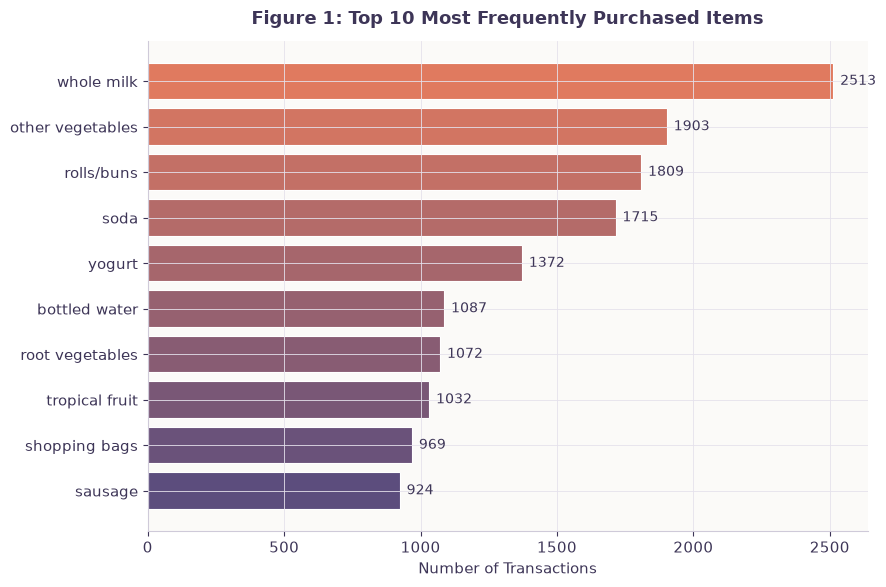

In [38]:
labels = [i for i, c in top10_items][::-1]
values = [c for i, c in top10_items][::-1]
colors = CMAP(np.linspace(0, 1, len(values)))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels, values, color=colors, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, values):
    ax.text(v + 25, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=10, color=DARK)
ax.set_xlabel('Number of Transactions')
ax.set_title('Figure 1: Top 10 Most Frequently Purchased Items', fontsize=13, fontweight='bold', color=DARK, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figure1_top10_items.png', dpi=150)
plt.show()

### Basket size overview

Looking beyond individual product counts, here we see how many products a customer usually buys in one trip. This helps us understand the typical basket size and the overall dataset.

In [39]:
basket_sizes = [len(t) for t in transactions]
avg_basket_size = np.mean(basket_sizes)
density = sum(basket_sizes) / (len(transactions) * len(items)) * 100

print(f"Average basket size: {avg_basket_size:.2f} items")
print(f"Largest basket: {max(basket_sizes)} items")
print(f"Smallest basket: {min(basket_sizes)} item(s)")
print(f"Transaction matrix density: {density:.2f}%")

Average basket size: 4.41 items
Largest basket: 32 items
Smallest basket: 1 item(s)
Transaction matrix density: 2.61%


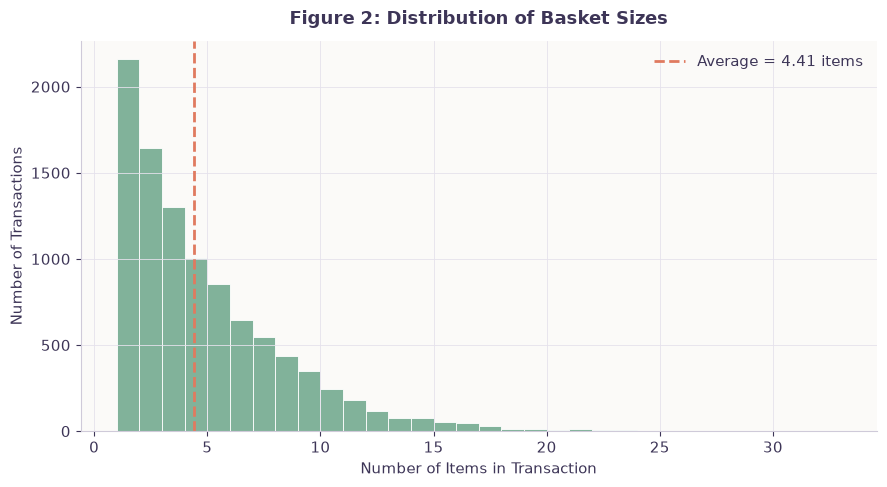

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
counts, bins, patches = ax.hist(basket_sizes, bins=range(1, max(basket_sizes)+2), color=SAGE, edgecolor='white', linewidth=0.6)
ax.axvline(avg_basket_size, color=TERRACOTTA, linestyle='--', linewidth=2, label=f'Average = {avg_basket_size:.2f} items')
ax.set_xlabel('Number of Items in Transaction')
ax.set_ylabel('Number of Transactions')
ax.set_title('Figure 2: Distribution of Basket Sizes', fontsize=13, fontweight='bold', color=DARK, pad=12)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figure2_basket_size_distribution.png', dpi=150)
plt.show()

The average basket contains roughly 4-5 items, and most transactions are small (a handful of items), with a long tail of larger baskets. The low transaction matrix density (~2-3%) confirms that, out of 169 possible items, any single transaction only ever contains a small fraction of them -- which is why Apriori's support-based filtering is essential for finding meaningful patterns rather than being overwhelmed by the sheer number of possible item combinations.

## Question 2: Frequent Itemsets

We convert the transaction list into a one-hot encoded basket matrix, then apply the Apriori algorithm to find itemsets that occur in at least 1% of all transactions (`min_support = 0.01`).

In [41]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_array, columns=te.columns_)

print(basket.shape)

(9835, 169)


The shape confirms 9,835 transactions and 169 unique items, matching Question 1.

In [42]:
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

multi_itemsets = frequent_itemsets[frequent_itemsets['length'] >= 2]
print(multi_itemsets['length'].value_counts())

length
2    213
3     32
Name: count, dtype: int64


In [43]:
top10_pairs = multi_itemsets.sort_values('support', ascending=False).head(10).reset_index(drop=True)
top10_pairs

,support,itemsets,length
0,0.074835,"frozenset({other vegetables, whole milk})",2
1,0.056634,"frozenset({rolls/buns, whole milk})",2
2,0.056024,"frozenset({whole milk, yogurt})",2
3,0.048907,"frozenset({root vegetables, whole milk})",2
4,0.047382,"frozenset({other vegetables, root vegetables})",2
5,0.043416,"frozenset({other vegetables, yogurt})",2
6,0.042603,"frozenset({other vegetables, rolls/buns})",2
7,0.042298,"frozenset({whole milk, tropical fruit})",2
8,0.040061,"frozenset({soda, whole milk})",2
9,0.038332,"frozenset({rolls/buns, soda})",2


**a & b. At least 10 frequent itemsets (2+ products) with their support values:** shown in the table above.

**c. Itemset with the highest support:** `{other vegetables, whole milk}`, support = 0.0748 (see row 0 of the table).

**d. What the support value tells us about purchasing behavior:** Support shows how often a group of items appears in all transactions. In other words, it tells us how common or popular that combination is.
The itemsets with the highest support, such as {other vegetables, whole milk}, {rolls/buns, whole milk}, and {yogurt, whole milk}, all include whole milk, which is also the most frequently purchased item.
This shows that these are common products that customers buy during their normal grocery shopping. They are not necessarily special or strongly related products; customers simply buy these basic items regularly. Support only shows how popular a combination is. 


For completeness, the top 10 itemsets containing exactly 3 products are shown below.

In [44]:
top10_triples = multi_itemsets[multi_itemsets['length'] == 3].sort_values('support', ascending=False).head(10).reset_index(drop=True)
top10_triples

,support,itemsets,length
0,0.023183,"frozenset({other vegetables, root vegetables, ...",3
1,0.022267,"frozenset({other vegetables, whole milk, yogurt})",3
2,0.017895,"frozenset({other vegetables, rolls/buns, whole...",3
3,0.017082,"frozenset({other vegetables, whole milk, tropi...",3
4,0.015557,"frozenset({rolls/buns, whole milk, yogurt})",3
5,0.015150,"frozenset({yogurt, whole milk, tropical fruit})",3
6,0.014642,"frozenset({other vegetables, whipped/sour crea...",3
7,0.014540,"frozenset({root vegetables, whole milk, yogurt})",3
8,0.013930,"frozenset({other vegetables, soda, whole milk})",3
9,0.013523,"frozenset({pip fruit, other vegetables, whole ...",3


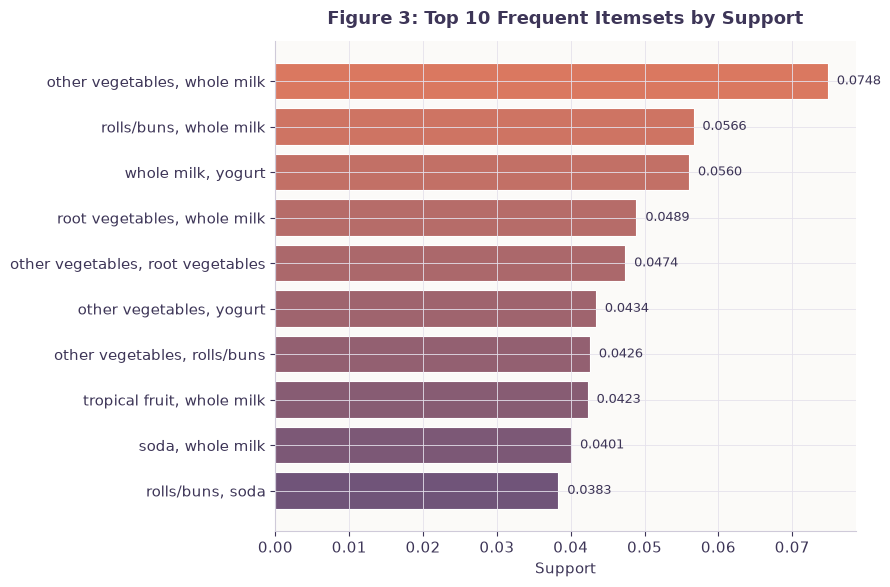

In [45]:
itemset_labels = [', '.join(sorted(s)) for s in top10_pairs['itemsets']][::-1]
itemset_values = top10_pairs['support'].values[::-1]
colors2 = CMAP(np.linspace(0.15, 0.95, len(itemset_values)))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(itemset_labels, itemset_values, color=colors2, edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, itemset_values):
    ax.text(v + 0.0012, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9, color=DARK)
ax.set_xlabel('Support')
ax.set_title('Figure 3: Top 10 Frequent Itemsets by Support', fontsize=13, fontweight='bold', color=DARK, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figure3_top10_itemsets.png', dpi=150)
plt.show()

## Question 3: Association Rules

Association rules were generated from the frequent itemsets using a minimum confidence threshold of 30%.

In [46]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
print(f"Total rules generated: {len(rules)}")

rules_table = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('confidence', ascending=False).head(10).reset_index(drop=True)
rules_table

Total rules generated: 125


,antecedents,consequents,support,confidence,lift
0,"frozenset({root vegetables, citrus fruit})",frozenset({other vegetables}),0.010371,0.586207,3.029608
1,"frozenset({root vegetables, tropical fruit})",frozenset({other vegetables}),0.012303,0.584541,3.020999
2,"frozenset({yogurt, curd})",frozenset({whole milk}),0.010066,0.582353,2.279125
3,"frozenset({other vegetables, butter})",frozenset({whole milk}),0.011490,0.573604,2.244885
4,"frozenset({root vegetables, tropical fruit})",frozenset({whole milk}),0.011998,0.570048,2.230969
5,"frozenset({root vegetables, yogurt})",frozenset({whole milk}),0.014540,0.562992,2.203354
6,"frozenset({other vegetables, domestic eggs})",frozenset({whole milk}),0.012303,0.552511,2.162336
7,"frozenset({whipped/sour cream, yogurt})",frozenset({whole milk}),0.010880,0.524510,2.052747
8,"frozenset({root vegetables, rolls/buns})",frozenset({whole milk}),0.012710,0.523013,2.046888
9,"frozenset({pip fruit, other vegetables})",frozenset({whole milk}),0.013523,0.517510,2.025351


**a. At least 10 association rules generated:** 125 total rules met the 30% confidence threshold; the top 10 (by confidence) are shown above.

**b. For each rule antecedent, consequent, support, confidence, lift:** all reported in the table above.

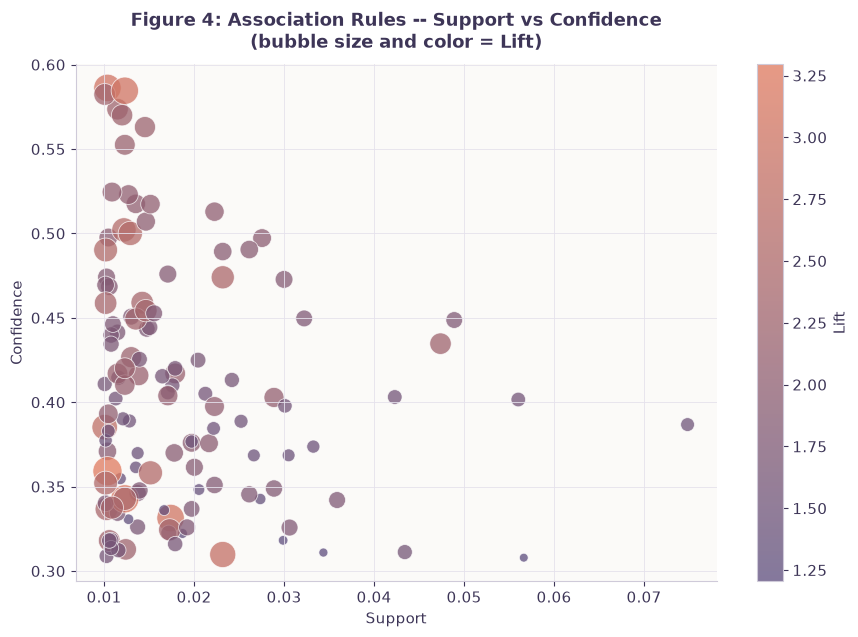

In [47]:
fig, ax = plt.subplots(figsize=(9, 6.5))
sizes = (rules['lift'] - rules['lift'].min()) / (rules['lift'].max() - rules['lift'].min()) * 400 + 40
sc = ax.scatter(rules['support'], rules['confidence'], s=sizes, c=rules['lift'],
                 cmap=CMAP, alpha=0.75, edgecolor='white', linewidth=0.6)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Lift', color=DARK)
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Figure 4: Association Rules -- Support vs Confidence\n(bubble size and color = Lift)', fontsize=13, fontweight='bold', color=DARK, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figure4_rules_scatter.png', dpi=150)
plt.show()

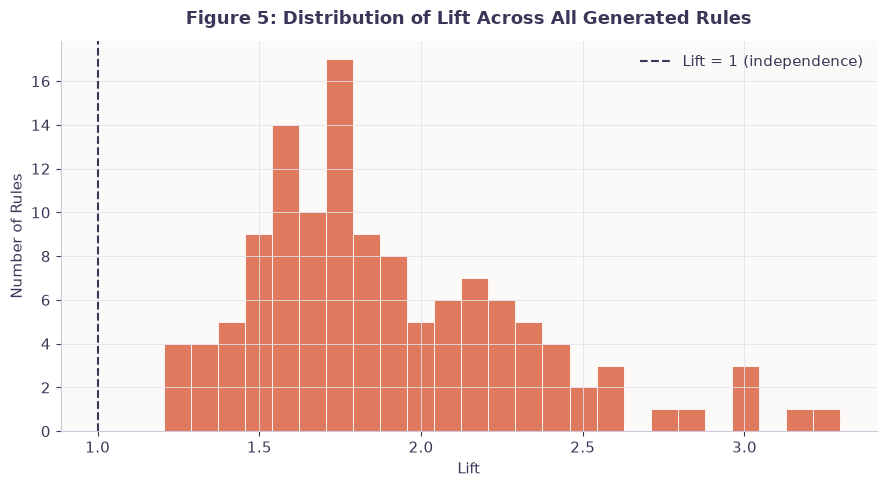

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rules['lift'], bins=25, color=TERRACOTTA, edgecolor='white', linewidth=0.6)
ax.axvline(1, color=DARK, linestyle='--', linewidth=1.5, label='Lift = 1 (independence)')
ax.set_xlabel('Lift')
ax.set_ylabel('Number of Rules')
ax.set_title('Figure 5: Distribution of Lift Across All Generated Rules', fontsize=13, fontweight='bold', color=DARK, pad=12)
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figure5_lift_distribution.png', dpi=150)
plt.show()

Most of the rules have a lift value above 1, which means that the items are often bought together more than we would expect by chance. However, the strength of these relationships is different, as shown in Figure 5.


## Question 4: Understanding the Measures

Three rules are selected from Question 3 to illustrate what support, confidence, and lift mean.

### Rule 1: {beef} -> {root vegetables}
Support = 0.0174, Confidence = 0.331, Lift = 3.04
- **Support:** Beef and root vegetables were bought together in 1.74% of all transactions.
- **Confidence:** Of customers who bought beef, 33.1% also bought root vegetables in the same trip.
- **Lift:** Customers who bought beef were about 3 times more likely to also buy root vegetables than a random customer -- a strong, non-coincidental association (likely for stews/roasts).

### Rule 2: {butter} -> {whole milk}
Support = 0.0276, Confidence = 0.497, Lift = 1.95
- **Support:** Butter and whole milk appeared together in 2.76% of all transactions.
- **Confidence:** Of customers who bought butter, 49.7% also bought whole milk.
- **Lift:** Buying butter makes a customer almost twice as likely to also buy whole milk compared to chance -- a solid, meaningful association.

### Rule 3: {bottled water} -> {whole milk}
Support = 0.0344, Confidence = 0.311, Lift = 1.22
- **Support:** Bottled water and whole milk appeared together in 3.44% of all transactions.
- **Confidence:** Of customers who bought bottled water, 31.1% also bought whole milk.
- **Lift:** A lift of only 1.22 (close to 1) means bottled water barely increases the likelihood of buying whole milk beyond chance -- a weak association, since whole milk is bought so often by everyone anyway.

## Question 5: Find Interesting Rules

We search across all generated rules (not just the top 10 shown earlier) for the single highest confidence, highest lift, and highest support.

In [49]:
highest_confidence = rules.sort_values('confidence', ascending=False).head(1)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
highest_lift = rules.sort_values('lift', ascending=False).head(1)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
highest_support = rules.sort_values('support', ascending=False).head(1)[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print("Highest confidence rule:")
print(highest_confidence)
print("\nHighest lift rule:")
print(highest_lift)
print("\nHighest support rule:")
print(highest_support)

Highest confidence rule:
                                   antecedents                    consequents  \
74  frozenset({root vegetables, citrus fruit})  frozenset({other vegetables})   

     support  confidence      lift  
74  0.010371    0.586207  3.029608  

Highest lift rule:
                                    antecedents                   consequents  \
73  frozenset({other vegetables, citrus fruit})  frozenset({root vegetables})   

     support  confidence      lift  
73  0.010371    0.359155  3.295045  

Highest support rule:
                      antecedents              consequents   support  \
53  frozenset({other vegetables})  frozenset({whole milk})  0.074835   

    confidence      lift  
53    0.386758  1.513634  


**a. Highest confidence:** {citrus fruit, root vegetables} -> {other vegetables}, confidence = 0.586

**b. Highest lift:** {citrus fruit, other vegetables} -> {root vegetables}, lift = 3.295

**c. Highest support:** {other vegetables} -> {whole milk}, support = 0.0748

**d. Are these the same rule? Explain:** No, all three are different rules, and this is expected rather than a coincidence, because each metric captures something different. Support rewards itemsets that are simply popular overall -- {other vegetables} and {whole milk} win here because they are individually the two most commonly bought items in the dataset, even though the relationship between them is not especially strong (lift only 1.51). Confidence rewards rules where the consequent reliably follows the antecedent regardless of overall popularity. Lift rewards the strongest genuine association relative to chance, independent of how common the items are. A rule can therefore be common (high support) without being a strong relationship, and a rare combination (low support) can still represent the strongest true association in the dataset -- which is exactly why all three metrics should be considered together rather than relying on any single one.

## Question 6: Interpret a Rule

**Selected rule: {citrus fruit, other vegetables} -> {root vegetables}**
Support = 0.0104, Confidence = 0.359, Lift = 3.295

**What it means** Customers who purchase citrus fruit and other vegetables together also tend to purchase root vegetables. Of all customers who bought citrus fruit and other vegetables in the same trip, about 36% also bought root vegetables roughly 3.3 times more often than would be expected if these purchases were unrelated.

**Strong or weak association, and why:** This is a strong association. The lift of 3.295 is well above 1, meaning the relationship is unlikely to be coincidental customers buying citrus fruit and other vegetables together are genuinely more inclined to also buy root vegetables, likely because all three are fresh produce commonly used together (e.g. for a stew, salad, or juicing). The one caveat is that support is low (1.04%), meaning this exact three-item combination is relatively rare overall, so while the relationship is strong when it occurs, it is a niche rather than everyday pattern.

## Question 7: Business Application

**a. Two products to place close to each other:**
Beef and root vegetables. This pair has a high lift of **3.04**, meaning that customers who buy beef are about 3 times more likely to also buy root vegetables than expected by chance. Placing root vegetables near the meat section could make it easier for customers to notice and buy them, which may increase the size of their basket.

**b. One possible product bundle:**
A **"Vegetable Stew" bundle** containing citrus fruit, other vegetables, and root vegetables could be offered. This combination has a high lift of **3.295**, meaning these products are often bought together. A discounted **"Fresh Stew Starter Pack"** could encourage customers who already like these products to buy them together.

**c. Example of using association rules for recommendations:**
The rule **{butter} → {whole milk}** has a confidence of **0.497** and a lift of **1.95**. This could be used in a **"Customers who bought this also bought..."** recommendation. For example, when a customer adds butter to their basket, the system could suggest whole milk. Since the rule has both good confidence and a meaningful lift, the recommendation is more likely to be relevant to the customer.


## Question 8: Understanding Association

**a. Does an association rule prove that one product causes customers to buy another product?**
No. Association rules only show that two products are often bought together. They do not explain why they are bought together. For example, the rule {butter} → {whole milk} does not mean that buying butter causes someone to buy whole milk. Both products may simply be common items that customers buy during the same shopping trip. Association rules show a relationship between items, but they do not prove cause and effect.

**b. Why might a rule have high confidence but low lift?**
This can happen when the item on the right side of the rule is already very popular. Confidence shows how often the second item is bought when the first item is bought, but it does not consider how popular the second item is overall.

For example, whole milk is bought in many transactions. Therefore, many different products may have high confidence with whole milk simply because whole milk is very common. Lift gives a better idea of whether the two items are actually related. This can result in high confidence but a lift close to 1, meaning the relationship may not be very strong.

For example, {bottled water} → {whole milk} has a confidence of 0.311, which seems fairly high, but its lift is only 1.22.

**c. What does a lift value greater than 1 indicate?**
A lift greater than 1 means that two items are bought together more often than we would expect by chance. The higher the lift is above 1, the stronger the relationship between the items.

* **Lift = 1:** The items are not meaningfully associated.
* **Lift > 1:** The items have a positive association.
* **Lift < 1:** The items have a negative association.

For example, a lift of 3 means that the two items are bought together about three times more often than expected by chance.


## Limitations

This analysis has several limitations worth noting:

1. The dataset does not contain customer identifiers, so customer-level purchasing behavior (e.g. loyalty, repeat patterns) cannot be studied.
2. There are no timestamps, so seasonal or time-of-day purchasing patterns cannot be analyzed.
3. Prices, quantities, and profit margins are not available, so the *financial* value of a rule (versus just its statistical strength) cannot be assessed.
4. Association rules describe correlation, not causation (see Question 8a).
5. Results depend on the chosen support and confidence thresholds -- a different threshold could surface different rules.
6. Some rules have high lift but low support, meaning they are statistically strong but numerically rare; both should be considered together, not in isolation.

Future extensions could include customer segmentation, time-based analysis, or A/B testing of rule-based product recommendations in a live store setting.

## References

1. Agrawal, R., & Srikant, R. (1994). *Fast Algorithms for Mining Association Rules*. Proceedings of the 20th VLDB Conference.
2. Raschka, S. (2018). *MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack*. Journal of Open Source Software, 3(24), 638.

## Summary

This analysis used the Apriori algorithm and association rule mining on the Groceries dataset (9,835 transactions, 169 unique items, average basket size ~4-5 items) to identify frequently co-purchased products and the strength of their relationships. Whole milk and other vegetables dominate in raw frequency and support, but the most genuinely interesting relationships -- as measured by lift -- involve fresh produce combinations such as citrus fruit, other vegetables, and root vegetables. These findings suggest practical applications for product placement, bundling, and recommendation systems in a supermarket setting.